In [ ]:
import pkg_resources
import os
os.system('cls')
installed_packages = pkg_resources.working_set
found = False
for package in installed_packages:
    if package.key == 'pyodbc':
        print(f"{package.key}=={package.version}")
        found = True
        break                 
if not found:
    print('Not Found')

C:\Users\Ayman\AppData\Local\Temp\ipykernel_20600\3317987642.py:1: DeprecationWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html



pyodbc==5.2.0


In [10]:
import pyodbc , pandas as pd
import os
os.system('cls')

import pyodbc

# Connect to your SQL Server Express
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=LAPTOP-O2H5FU1M\\SQLEXPRESS;"
    "DATABASE=master;"  # or any other database name
    "Trusted_Connection=yes;"
)

cursor = conn.cursor()

# Your SQL queries here
cursor.execute("SELECT name FROM sys.databases ORDER BY name")
results = cursor.fetchall()
df = pd.DataFrame(results, columns=['Database Name'])
print(df)

# Don't forget to close
cursor.close()
conn.close()

            Database Name
0  [AdventureWorksLT2022]
1                [master]
2                 [model]
3                  [msdb]
4               [SonicDB]
5                [tempdb]
6                [TestDB]
7               [Thunder]


In [15]:
import pyodbc 
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=LAPTOP-O2H5FU1M\\SQLEXPRESS;"
    "DATABASE=master;"  # or any other database name
    "Trusted_Connection=yes;",
    autocommit=True 
)

cursor = conn.cursor()
cursor.execute("""
IF NOT EXISTS (SELECT name FROM sys.databases WHERE name = 'SonicDB')
BEGIN
    CREATE DATABASE SonicDB;
END
""")
conn.commit()
print("Database created successfully.")

cursor.execute(f"USE TestDB")

# Now you can run queries on that database
df = pd.read_sql_query("SELECT *  FROM Mydatasheet", conn)
display(df)
# Don't forget to close
cursor.close()
conn.close()



Database created successfully.


,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [ ]:
import pyodbc
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Simple SQL Server connection with pandas
server = 'LAPTOP-O2H5FU1M\\SQLEXPRESS'
database = 'master'

try:
    # Connect to SQL Server
    conn = pyodbc.connect(
        f'DRIVER={{ODBC Driver 17 for SQL Server}};'
        f'SERVER={server};'
        f'DATABASE={database};'
        f'Trusted_Connection=yes;'
    )
    
    print("✅ Connected to SQL Server!")
    
    # Example 1: Simple query to pandas DataFrame
    query1 = "SELECT name, database_id, create_date FROM sys.databases"
    df1 = pd.read_sql(query1, conn)
    print("\n📊 Databases:")
    print(df1)
    
    # Example 2: Query with pandas formatting
    query2 = """
    SELECT 
        @@SERVERNAME as ServerName,
        @@VERSION as Version,
        GETDATE() as CurrentTime
    """
    df2 = pd.read_sql(query2, conn)
    print("\n📊 Server Info:")
    print(df2)
    
    # Example 3: Save DataFrame to CSV
    df1.to_csv('databases.csv', index=False)
    print("\n💾 Saved databases list to 'databases.csv'")


    
    # Close connection
    conn.close()
    print("\n✅ Connection closed")
    
except Exception as e:
    print(f"❌ Error: {e}")



✅ Connected to SQL Server!

📊 Databases:
                   name  database_id             create_date
0                master            1 2003-04-08 09:13:36.390
1                tempdb            2 2025-07-25 17:50:54.527
2                 model            3 2003-04-08 09:13:36.390
3                  msdb            4 2022-10-08 06:31:57.550
4  AdventureWorksLT2022            5 2024-09-26 20:15:10.597
5                TestDB            6 2025-07-24 19:28:29.307
6               Thunder            7 2025-07-26 00:02:30.910
7               SonicDB            8 2025-07-26 00:10:37.567

📊 Server Info:
                   ServerName  \
0  LAPTOP-O2H5FU1M\SQLEXPRESS   

                                             Version             CurrentTime  
0  Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 ... 2025-07-26 02:24:29.620  

💾 Saved databases list to 'databases.csv'

✅ Connection closed


ProgrammingError: Attempt to use a closed connection.

In [5]:
# Two Very Simple Plotly Examples

# Example 1: Simple Line Plot
import plotly.express as px

# Simple data
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# Create and save line plot
fig1 = px.line(x=x, y=y, title="Simple Line Plot")
fig1.show()
print("Line plot saved as line_plot.html")

# Example 2: Simple Scatter Plot

# Simple data
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

# Create and save scatter plot
fig2 = px.scatter(x=x, y=y, title="Simple Scatter Plot")
fig2.show()
print("Scatter plot saved as scatter_plot.html")

# Display multiple plots in a single cell using plotly.subplots
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create a subplot with 1 row and 2 columns
fig = make_subplots(rows=1, cols=2, subplot_titles=("Line Plot", "Scatter Plot"))

# Add the line plot to the first subplot
fig.add_trace(
    go.Scatter(x=[1, 2, 3, 4, 5], y=[2, 4, 6, 8, 10], mode='lines+markers', name='Line'),
    row=1, col=1
)

# Add the scatter plot to the second subplot
fig.add_trace(
    go.Scatter(x=[1, 2, 3, 4, 5], y=[1, 4, 9, 16, 25], mode='markers', name='Scatter'),
    row=1, col=2
)

fig.update_layout(title_text="Multiple Plots in a Single Figure", showlegend=False)
fig.show()



Line plot saved as line_plot.html


Scatter plot saved as scatter_plot.html


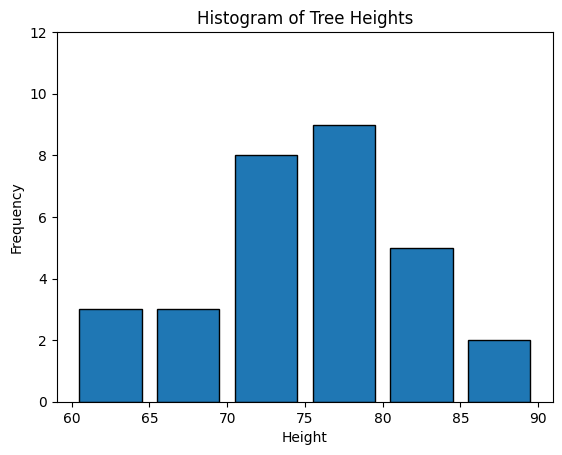

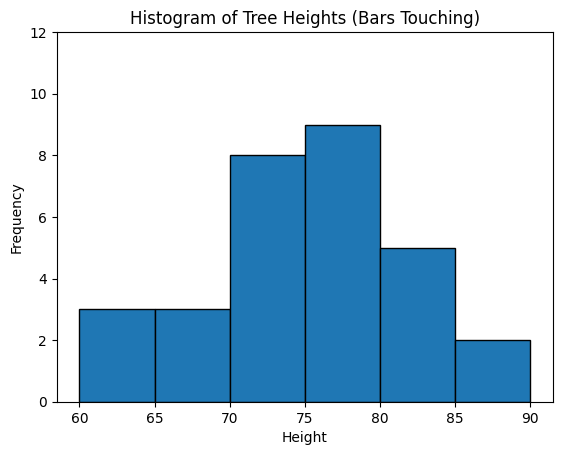

In [1]:
tree_hight =  [61, 63, 64, 66, 68, 69, 71, 71.5, 72, 72.5, 73, 73.5, 74, 74.5, 76, 76.2, 76.5, 77, 77.5, 78, 78.5, 79, 79.2, 80, 81, 82, 83, 84, 85, 87]
import matplotlib.pyplot as plt

# Calculate and create histogram
# Adjust bins so that 71-75 and 76-80 are separate bins and frequencies are shown correctly
bins = [60, 65, 70, 75, 80, 85, 90]  # Custom bins to isolate 71-75 and 76-80
plt.hist(tree_hight, bins=bins, edgecolor='black', rwidth=0.8)
plt.title('Histogram of Tree Heights')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.ylim(0, 12)  # Set frequency (y-axis) a bit higher to show the bar reaching 10
plt.show()
# To make the bars touch each other, set rwidth=1 (full width, no gap between bars)
plt.hist(tree_hight, bins=bins, edgecolor='black', rwidth=1)
plt.title('Histogram of Tree Heights (Bars Touching)')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.ylim(0, 12)
plt.show()


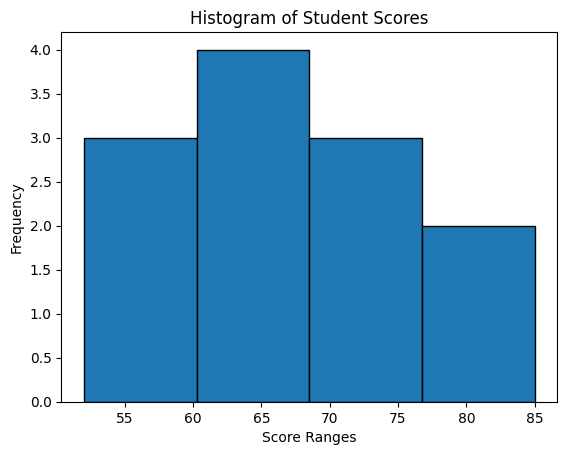

In [27]:
import matplotlib.pyplot as plt

data = [52, 55, 60, 61, 62, 65, 68, 70, 72, 75, 80, 85]

plt.hist(data, bins=4, edgecolor='black')
plt.title("Histogram of Student Scores")
plt.xlabel("Score Ranges")
plt.ylabel("Frequency")
plt.show()


In [1]:
import numpy as np
np.random.seed(1)
data = np.random.normal(loc=350, scale=50, size=100).astype(int)
print(data.min())

234


In [1]:
from sklearn import svm
from sklearn.metrics import hinge_loss

# Input features and labels
X = [[0], [1]]
y = [-1, 1]

# Train linear SVM classifier
model = svm.LinearSVC()
model.fit(X, y)

# Predict raw decision scores
decision_scores = model.decision_function(X)

# Calculate hinge loss
loss = hinge_loss(y, decision_scores)
print("Hinge Loss:", loss)


import numpy as np

scores = decision_scores  # use actual values from decision_scores
y_true = np.array([-1, 1])

losses = np.maximum(0, 1 - y_true * scores)
print("Individual hinge losses:", losses)
print("Average hinge loss:", losses.mean())



Hinge Loss: 0.5454545454545454
Individual hinge losses: [0.63636364 0.45454545]
Average hinge loss: 0.5454545454545454


In [3]:
 import numpy as np
from sklearn.svm import SVC

# Use only two points that we used in manual derivation
X = np.array([
    [2, 2],   # class -1
    [4, 5]    # class +1
])
y = np.array([-1, 1])

# Train hard-margin linear SVM
model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

# Extract weights and bias
w = model.coef_[0]
b = model.intercept_[0]

# Print result
print("Weights (w):", w)
print("Bias (b):", b)

# Check closeness to manual
w_manual = np.array([2/11, 6/11])
b_manual = -27/11

print("\nManual Weights:", w_manual)
print("Manual Bias:", b_manual)

print("\nClose match? w:", np.allclose(w, w_manual), ", b:", np.allclose(b, b_manual))


Weights (w): [0.30769231 0.46153846]
Bias (b): -2.5384615384615388

Manual Weights: [0.18181818 0.54545455]
Manual Bias: -2.4545454545454546

Close match? w: False , b: False


In [4]:
import numpy as np
from sklearn.svm import SVC

# Define just the 2 support vectors from manual case
X = np.array([
    [2, 2],   # class -1
    [4, 5]    # class +1
])
y = np.array([-1, 1])  # -1 for (2,2), +1 for (4,5)

# Train hard-margin linear SVM
model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

# Get weights and bias
w = model.coef_[0]
b = model.intercept_[0]

print("Weights (w):", w)
print("Bias (b):", b)

# Manually computed values
w_manual = np.array([2/11, 6/11])
b_manual = -27/11

print("\nExpected w:", w_manual)
print("Expected b:", b_manual)

print("\nMatch? w:", np.allclose(w, w_manual), ", b:", np.allclose(b, b_manual))


Weights (w): [0.30769231 0.46153846]
Bias (b): -2.5384615384615388

Expected w: [0.18181818 0.54545455]
Expected b: -2.4545454545454546

Match? w: False , b: False
